In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

# Modelos de árvore
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Rede neural
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Interpretabilidade
import shap
from sklearn.inspection import permutation_importance

# Salvamento
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

SEED = 42
np.random.seed(SEED)
print("Ambiente configurado.")

Ambiente configurado.


In [3]:
df = pd.read_parquet("data/gold/gold_escolas_evasao.parquet")
print(f"Dimensões originais: {df.shape}")

# Features a serem removidas (usadas na criação do target)
cols_regra = ['QT_TUR_EJA', 'prop_turmas_eja', 'QT_DOC_BAS', 'QT_TUR_BAS', 'docentes_por_turma']
df_clean = df.drop(columns=[c for c in cols_regra if c in df.columns], errors='ignore')
print(f"Dimensões após remoção: {df_clean.shape}")

# Verificar distribuição do target
print("\nDistribuição do target:")
print(df_clean['target_evasao'].value_counts(normalize=True))

df_clean.head()

Dimensões originais: (178772, 16)
Dimensões após remoção: (178772, 11)

Distribuição do target:
target_evasao
0    0.727782
1    0.272218
Name: proportion, dtype: float64


,CO_ENTIDADE,CO_MUNICIPIO,CO_UF,QT_DOC_BAS_FEM,QT_DOC_BAS_MASC,QT_GESTORES,QT_TUR_MED,QT_TUR_PROF,tem_ensino_medio,tem_profissional,target_evasao
0,11022558,1100015,11,0.0,1.0,1.0,0.0,0.0,0,0,1
1,11024275,1100015,11,5.0,4.0,1.0,0.0,0.0,0,0,1
2,11024666,1100015,11,10.0,3.0,1.0,0.0,0.0,0,0,0
3,11024682,1100015,11,24.0,20.0,1.0,28.0,5.0,1,1,0
4,11024917,1100015,11,8.0,3.0,1.0,0.0,0.0,0,0,0


Top 10 Estados com maior proporção de risco:


,UF,total_escolas,escolas_risco,proporcao_risco
15,BA,15854,7407,0.467201
13,AL,2851,1276,0.447562
1,AC,1521,645,0.424063
4,PA,10472,3942,0.376432
2,AM,5536,2043,0.369039
5,AP,864,314,0.363426
12,PE,7968,2860,0.358936
0,RO,1186,421,0.354975
11,PB,4624,1640,0.354671
8,PI,3976,1402,0.352616


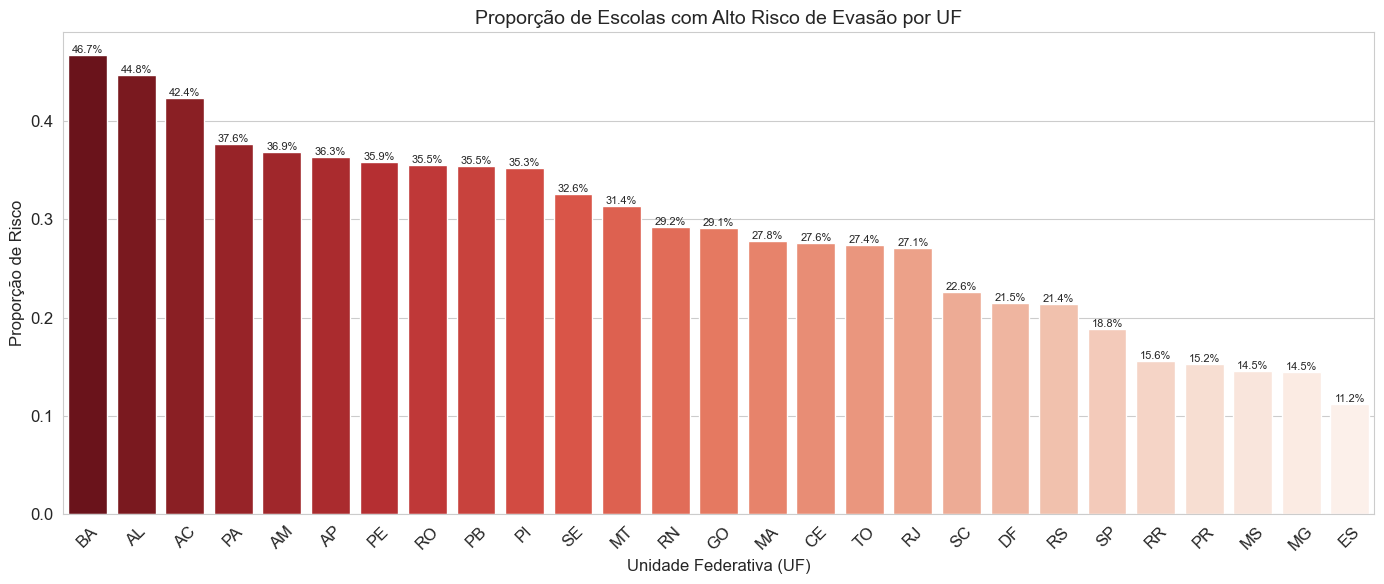

In [5]:
# %% [code]
# 4.1 Distribuição do Risco por UF (com siglas)

# Mapeamento oficial IBGE: código -> sigla
mapa_uf = {
    11: 'RO', 12: 'AC', 13: 'AM', 14: 'RR', 15: 'PA', 16: 'AP', 17: 'TO',
    21: 'MA', 22: 'PI', 23: 'CE', 24: 'RN', 25: 'PB', 26: 'PE', 27: 'AL',
    28: 'SE', 29: 'BA',
    31: 'MG', 32: 'ES', 33: 'RJ', 35: 'SP',
    41: 'PR', 42: 'SC', 43: 'RS',
    50: 'MS', 51: 'MT', 52: 'GO', 53: 'DF'
}

# Agrupar por UF e mapear sigla
uf_stats = df_clean.groupby('CO_UF').agg(
    total_escolas=('target_evasao', 'count'),
    escolas_risco=('target_evasao', 'sum')
).reset_index()
uf_stats['UF'] = uf_stats['CO_UF'].map(mapa_uf)
uf_stats['proporcao_risco'] = uf_stats['escolas_risco'] / uf_stats['total_escolas']
uf_stats = uf_stats.sort_values('proporcao_risco', ascending=False)

# Exibir tabela com as 10 maiores
print("Top 10 Estados com maior proporção de risco:")
display(uf_stats[['UF', 'total_escolas', 'escolas_risco', 'proporcao_risco']].head(10))

# Gráfico de barras
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=uf_stats, x='UF', y='proporcao_risco', 
                 order=uf_stats['UF'], palette='Reds_r')
plt.title('Proporção de Escolas com Alto Risco de Evasão por UF', fontsize=14)
plt.xlabel('Unidade Federativa (UF)')
plt.ylabel('Proporção de Risco')
plt.xticks(rotation=45)
# Adicionar rótulos com o valor exato em cima das barras (opcional)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()